## Sentiment analysis using classical NLP methods

In [21]:
# IMPORT LIBRARIES

# Exploratory data analysis (EDA) and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots appear in the notebook
%matplotlib inline

# Text processing libraries
import re
import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.util import mark_negation
from bs4 import BeautifulSoup
import contractions
import emoji


# Download necessary NLTK resources

nltk.download('stopwords') # stopwords is a collection of common words to be filtered out
nltk.download('wordnet') # WordNet is a lexical database for the English language
nltk.download('omw-1.4') # Open Multilingual WordNet is a multilingual extension of WordNet
nltk.download('vader_lexicon') # VADER lexicon is used for sentiment analysis
nltk.download('punkt') # Punkt tokenizer is a pre-trained model for tokenizing text
nltk.download('punkt_tab') # Punkt tokenizer (tab-separated) is a pre-trained model for tokenizing text with tab characters
nltk.download('averaged_perceptron_tagger_eng') # POS tagger for English

## Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

## Model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Miscellaneous
import joblib
import os

# Print last updated timestamp
import time
print(f"Last updated: {time.asctime()}")

Last updated: Thu Dec 18 22:32:40 2025


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\IrfanF\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\IrfanF\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\IrfanF\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\IrfanF\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\IrfanF\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\IrfanF\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_p

In [22]:
# LOAD DATA

# Amazon Fine Food Reviews dataset from Kaggle https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

# Load dataset
df = pd.read_csv('../data/Reviews.csv')
df.shape

(568454, 10)

In [23]:
# inspect data
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [24]:
# NUMBER OF MISSING VALUES PER COLUMN

missing_per_column = df.isna().sum()
print(missing_per_column)

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


In [25]:
# DATAFRAME INFO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [26]:
# STATISTICAL SUMMARY OF THE DATAFRAME
df.describe(include='all')

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
count,568454.000000,568454,568454,568428,568454.000000,568454.00000,568454.000000,5.684540e+05,568427,568454
unique,NaN,74258,256059,218415,NaN,NaN,NaN,NaN,295742,393579
top,NaN,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",NaN,NaN,NaN,NaN,Delicious!,"This review will make me sound really stupid, ..."
freq,NaN,913,448,451,NaN,NaN,NaN,NaN,2462,199
mean,284227.500000,NaN,NaN,NaN,1.743817,2.22881,4.183199,1.296257e+09,NaN,NaN
std,164098.679298,NaN,NaN,NaN,7.636513,8.28974,1.310436,4.804331e+07,NaN,NaN
min,1.000000,NaN,NaN,NaN,0.000000,0.00000,1.000000,9.393408e+08,NaN,NaN
25%,142114.250000,NaN,NaN,NaN,0.000000,0.00000,4.000000,1.271290e+09,NaN,NaN
50%,284227.500000,NaN,NaN,NaN,0.000000,1.00000,5.000000,1.311120e+09,NaN,NaN
75%,426340.750000,NaN,NaN,NaN,2.000000,2.00000,5.000000,1.332720e+09,NaN,NaN


In [27]:
# IDENTIFY COLUMN DATA TYPES

num_cols = df.select_dtypes(include=[np.number, 'int64', 'float64']).columns
print("Numeric columns", num_cols)
cat_cols = df.select_dtypes(include=['category', 'object']).columns
print("Categorical columns", cat_cols)
date_cols = list(df.select_dtypes(include=['datetime64']).columns)
print("Date columns", date_cols)

Numeric columns Index(['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score',
       'Time'],
      dtype='object')
Categorical columns Index(['ProductId', 'UserId', 'ProfileName', 'Summary', 'Text'], dtype='object')
Date columns []


In [28]:
# Use 10% of the dataframe randomly (for faster processing during development)
df = df.sample(frac=0.1, random_state=42)
df.shape

(56845, 10)

In [29]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [30]:
#  Text preprocessing - advanced version with POS tagging, negation handling, number replacement, and contraction expansion

# Map NLTK POS tags to WordNet POS tags for lemmatization
def get_wordnet_pos(word):
    """Map POS tag to WordNet POS tag"""
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN) # Default to noun

def preprocess_text(text):
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Demojize emojis
    text = emoji.demojize(text)
    
    # Expand contractions (e.g. "don't" -> "do not")
    text = contractions.fix(text)
    
    # Lowercase
    text = text.lower()
    
    # Replace numbers with a special token
    text = re.sub(r'\d+', ' <num> ', text)
    
    # Remove non-alphabetic characters (keep <num>)
    text = re.sub(r'[^a-zA-Z\s<>]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Keep only alphabetic tokens and <num>
    tokens = [w for w in tokens if w.isalpha() or w == '<num>']
    
    # Negation handling (optional; skip if using pretrained embeddings)
    tokens = mark_negation(tokens)
    
    # POS tagging
    pos_tags = pos_tag(tokens)
    
    # Lemmatize + remove stopwords
    clean_tokens = []

    for word, _ in pos_tags:
        # Skip stopwords, but keep negation-marked words
        if word in stop_words and not word.endswith('_NEG'):
            continue
        
        # Get WordNet POS for the word
        pos = get_wordnet_pos(word)
        
        # Lemmatize the word using the correct POS
        lemma = lemmatizer.lemmatize(word, pos)
        
        clean_tokens.append(lemma)

    # Remove very short words (except negations)
    clean_tokens = [w for w in clean_tokens if len(w) > 2 or w.endswith('_NEG')]
    
    return ' '.join(clean_tokens)



# Apply to dataframe
df['cleaned_text'] = df['Text'].apply(preprocess_text)

C:\Users\IrfanF\AppData\Local\Temp\ipykernel_15404\1630961985.py:17: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()


In [31]:
# DISTRIBUTION OF SENTIMENT LABELS (BEFORE CONVERSION)
df.Score.value_counts()

Score
5    36514
4     7982
1     5178
3     4267
2     2904
Name: count, dtype: int64

In [32]:
# CONVERTING SCORES TO SENTIMENT LABELS

# Convert scores (1–5) into binary sentiment (for binary classification)
df = df[df['Score'] != 3]  # remove neutral reviews
df['sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)


In [33]:
# DISTRIBUTION OF SENTIMENT LABELS
df.sentiment.value_counts()


sentiment
1    44496
0     8082
Name: count, dtype: int64

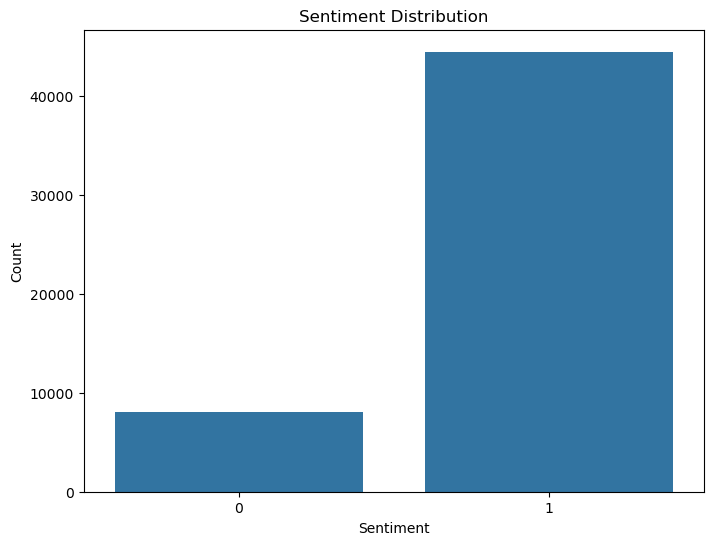

In [34]:
# PLOTTING SENTIMENT DISTRIBUTION
fig = plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


In [35]:
# SPLITTING DATA INTO TRAINING AND TEST SETS
# Using test_size=0.1 to match transformer notebook and run_evaluate.py

X = df['cleaned_text']
y = df['sentiment'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Shapes: X_train={X_train.shape}, X_test={X_test.shape}, y_train={y_train.shape}, y_test={y_test.shape}')

Train: 47320, Test: 5258
Shapes: X_train=(47320,), X_test=(5258,), y_train=(47320,), y_test=(5258,)


In [36]:
# TEXT VECTORIZATION USING TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limit features for efficiency
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)

print(X_train.shape, X_test.shape)


(47320, 5000) (5258, 5000)


In [37]:
print(X_train.shape, X_test.shape)
print(X_train.dtype, X_test.dtype)

(47320, 5000) (5258, 5000)
float64 float64


In [38]:
np.random.seed(42)

In [39]:
# TRAIN AND EVALUATE THE MODEL

# Using Logistic Regression (use it with TF-IDF or Bag of Words)
model = LogisticRegression(solver='saga', max_iter=1000, class_weight='balanced') # 'saga' for large datasets

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8847470521110689
              precision    recall  f1-score   support

           0       0.57      0.86      0.69       776
           1       0.97      0.89      0.93      4482

    accuracy                           0.88      5258
   macro avg       0.77      0.88      0.81      5258
weighted avg       0.92      0.88      0.89      5258



In [40]:
# SAVE THE MODEL AND VECTORIZER
model_filename = '../models/classical_models/logistic_tfidf_model.pkl'
vectorizer_filename = '../models/classical_models/tfidf_vectorizer.pkl'
joblib.dump(model, model_filename)
joblib.dump(tfidf_vectorizer, vectorizer_filename)

['../models/classical_models/tfidf_vectorizer.pkl']